In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar,Jars/graphframes-0.8.2-spark3.0-s_2.12.jar")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-08 04:01:36.654309


26/07/08 04:01:37 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 04:01:37 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 04:01:38 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 04:01:38 WARN  spark.SparkConf: [Thread-10]: The configuration key 'spark.maxRemoteBlockSizeFetc

New Spark Session created at :  2026-07-08 04:01:51.742594
Logs level set to ERROR


----------------------------------------
Exception happened during processing of request from ('127.0.0.1', 53126)
Traceback (most recent call last):
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 747, in __init__
    self.handle()
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 282, in handle
    poll(accum_updates)
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 253, in poll
    if func():
  File "/opt/cloud

# Notebook 05 (v2) — MOTIF features (shared-beneficiary, ATM cash-out, layering rings, Fraudar)

Adds **structural motif** features on top of notebook 04's node features, using the SAME hard-won design:
* **RARE graph only** (transfer beneficiaries with window fan-in <= `RARE_BENEF_MAX`, ATM terminals <=
  `RARE_ATM_MAX`). Motifs on the full graph are drowned by common merchants / public ATMs — the exact
  saturation that killed the signal before. Rare filtering is what made shared-beneficiary discriminative.
* **Leak-free**: only the anchor's trailing-3-month edges; the shared-* motifs are anchored on SEEDS
  (historical-bad accounts); `target_fraud` is NEVER used to build a feature (held out for scoring only).
  Self-seeds are excluded from candidates (a known-bad candidate would score trivially).
* **Incremental-then-select OVER 04**: the baseline ensemble is 04's established signal
  (`n_shared_mule` + `closeness_to_bad`); each motif is added one at a time and we log its MARGINAL lift.

The four motif families (mentor-directed):
1. **Shared-beneficiary collector ring** — candidate pays a rare mule that a known fraud also pays; we add
   the RING SIZE (`ring_co_feeders` = how many other accounts feed those mules) and the biggest collector
   (`max_shared_mule_fanin`). (`n_shared_mule_motif` is computed only to cross-check 04.)
2. **ATM cash-out** — candidate withdraws at a rare ATM/POS terminal a known fraud also used (`n_shared_atm`).
3. **Layering rings** — directed 3-cycle a->b->c->a (circular money movement to obscure origin), via the
   GraphFrames `find()` motif DSL (with a plain-join fallback): `on_3cycle`, `n_3cycle_as_a`.
4. **Fraudar (inspired)** — dense bipartite block of accounts x rare mules, scored with Fraudar's logarithmic
   column weighting + a 2-pass density spread (`fraudar_score`). This is the Fraudar *intuition* (suspicious
   dense blocks), NOT the full greedy-peeling algorithm — labelled honestly.

Reads 04's `_v2_cust_features`. Writes account-/customer-level motif features, an incremental-lift log
(capture@K over 04's baseline), and a binning/sloping table. Run AFTER 04 (and 04b). Run session cells first.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark import StorageLevel
import numpy as np
import pandas as pd

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
EDGES_TXN  = f"{WRITE_DB}.{EMP}_v2_edges_transferred"     # nb 02b: src, dst, txn_month, sum_amount
EDGES_ATM  = f"{WRITE_DB}.{EMP}_v2_edges_withdrew"        # nb 02b: src=acct, dst=atm_pos_id, txn_month
SUBG_NIDX  = f"{WRITE_DB}.{EMP}_v2_subgraph_node_index"   # nb 03 : id, is_known_bad, is_candidate, target_fraud, anchor_month
OWN_TBL    = f"{WRITE_DB}.{EMP}_v2_edges_ownership"       # nb 02 : src=cust, dst=acct
FEATS_CUST = f"{WRITE_DB}.{EMP}_v2_cust_features"         # nb 04 : CUSTOMER features (baseline to beat) — must exist

# anchor -> trailing 3 months (leak-free, identical to nb 03/04)
ANCHOR_TRAILING = {
    "202509": ["202506", "202507", "202508"],
    "202510": ["202507", "202508", "202509"],
    "202511": ["202508", "202509", "202510"],
}

TEST_ONE_ANCHOR = False         # FINAL: run all three anchors together (Sep/Oct/Nov), matching 04
USE_GRAPHFRAMES = True          # True -> GraphFrames find() for the 3-cycle motif; False -> plain-join fallback
RARE_BENEF_MAX  = 20            # keep transfer edges only to beneficiaries with window fan-in <= this (match 04)
RARE_ATM_MAX    = 500           # keep ATM edges only to terminals used by <= this many distinct accounts (tunable:
                                # drops mega-public ATMs while keeping neighbourhood terminals — same rare-node logic)
K_PCTS          = [0.01, 0.05, 0.10]

# Distributed Fraudar = Bahmani et al. batch-peeling densest-subgraph (multi-block). Each round removes ALL
# nodes with weighted degree <= 2(1+eps)*density -> converges in ~log_(1+eps) n BOUNDED rounds (NOT one node at
# a time), each round a few Spark aggregations + a reliable HDFS checkpoint -> same safe envelope as the PPR loop,
# NO driver collect. Finds dense bipartite blocks of accounts x rare mules (rings sharing cash-out infra) and
# flags membership. A (2+2eps)-approximation to the optimal densest subgraph. Set False to skip (the cheap
# single-pass fraudar_score companion still runs).
RUN_REAL_FRAUDAR   = True
FRAUDAR_EPS        = 1.0        # bigger -> fewer rounds, looser approximation
FRAUDAR_MAX_ROUNDS = 20         # safety cap on peeling rounds per block
FRAUDAR_MAX_BLOCKS = 6          # peel up to this many dense blocks (multi-block coverage; one global block is too narrow)
FRAUDAR_MIN_ACCT   = 3          # ignore trivial blocks with fewer accounts than this
FRAUDAR_MAX_ACCT   = 5000       # a fraud RING is small; skip flagging "blocks" bigger than this (they're the graph bulk,
                                # not a ring — without this, densest-subgraph degenerates to millions of accounts -> IV=0)

OUT_MOTIF           = f"{WRITE_DB}.{EMP}_v2_motif_features"        # account-level motif features
OUT_MOTIF_CUST      = f"{WRITE_DB}.{EMP}_v2_motif_cust_features"   # customer-level motif rollup
OUT_MOTIF_CUST_FULL = f"{WRITE_DB}.{EMP}_v2_motif_cust_full"       # 04 cust features + motifs (for lift/sloping/plots)
OUT_MOTIF_LIFT      = f"{WRITE_DB}.{EMP}_v2_motif_increment_lift"
OUT_MOTIF_SLOPE     = f"{WRITE_DB}.{EMP}_v2_motif_sloping"

# 05's graph is the SMALL rare graph; the session's spark.sql.shuffle.partitions=12000 is sized for 02b's
# billions-row scan and over-partitions every join into ~12000 near-empty tasks. 256 is plenty and far faster.
spark.conf.set("spark.sql.shuffle.partitions", "256")

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

anchors = (["202509"] if TEST_ONE_ANCHOR else list(ANCHOR_TRAILING.keys()))
print("anchors:", anchors, "| rare benef <=", RARE_BENEF_MAX, "| rare ATM <=", RARE_ATM_MAX,
      "| GraphFrames:", USE_GRAPHFRAMES, "| shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))


anchors: ['202509', '202510', '202511'] | rare benef <= 20 | rare ATM <= 500 | GraphFrames: True | shuffle.partitions: 256


## A0. GraphFrames setup (for the layering-cycle motif `find()`). No Pregel here -> not the fragile path.


In [4]:
GF_JAR   = "Jars/graphframes-0.8.2-spark3.0-s_2.12.jar"
CKPT_DIR = f"hdfs:///user/{user_id}/gf_ckpt"
GraphFrame = None
spark.sparkContext.setCheckpointDir(CKPT_DIR)          # reliable HDFS checkpoints (survive executor loss)
if USE_GRAPHFRAMES:
    try:
        spark.sparkContext.addPyFile(GF_JAR)
        from graphframes import GraphFrame
        print("GraphFrames enabled (find() motif DSL available).")
    except Exception as ge:
        GraphFrame = None
        print("GraphFrames import failed — 3-cycle motif will use the plain-join fallback:", ge)


GraphFrames enabled (find() motif DSL available).


## A. Substrate per anchor — RARE transfer graph + seeds + candidates (same recipe as nb 04)


In [5]:
def build_substrate(anchor):
    months = ANCHOR_TRAILING[anchor]
    e0 = (spark.table(EDGES_TXN).where(F.col("txn_month").isin(*months))
          .select("src", "dst", F.col("sum_amount").cast("double").alias("amt"))
          .where(F.col("src") != F.col("dst")).persist(StorageLevel.DISK_ONLY))
    # keep ONLY rare/private beneficiaries (window fan-in <= cap) -> strips merchant saturation
    fanin = e0.groupBy("dst").agg(F.countDistinct("src").alias("fi"))
    rare  = fanin.where(F.col("fi") <= RARE_BENEF_MAX).select("dst", "fi").persist(StorageLevel.DISK_ONLY)
    e = (e0.join(rare.select("dst"), "dst", "inner")
         .groupBy("src", "dst").agg(F.sum("amt").alias("amt"))
         .select("src", "dst", F.log1p(F.col("amt")).alias("weight")).persist(StorageLevel.DISK_ONLY))
    e.count(); rare.count(); e0.unpersist()
    lab = spark.table(SUBG_NIDX).where(F.col("anchor_month") == anchor)
    seeds = lab.where(F.col("is_known_bad") == 1).select("id").distinct()
    cands = (lab.where((F.col("is_candidate") == 1) & (F.col("is_known_bad") == 0))
             .select("id", F.col("target_fraud").cast("int").alias("target_fraud")))
    return e, rare, seeds, cands


## B. Motif 1 — SHARED-BENEFICIARY collector ring (ring size + biggest collector)
`e` is already rare-only, so every dst is a private payee. Anchored on SEEDS (leak-free).


In [6]:
def motif_shared_benef(e, rare, seeds):
    seed_benef = (e.join(seeds.select(F.col("id").alias("src")), "src").select("dst").distinct())  # rare mules a seed pays
    cand_mule  = e.join(seed_benef, "dst").select("src", "dst").distinct()                          # (account, seed-shared mule)
    base   = cand_mule.groupBy("src").agg(F.countDistinct("dst").alias("n_shared_mule_motif"))      # cross-check vs 04
    fanin  = cand_mule.join(rare, "dst").groupBy("src").agg(F.max("fi").alias("max_shared_mule_fanin"))  # biggest collector
    cofeed = (e.select(F.col("src").alias("other"), "dst").join(cand_mule.select("src", "dst"), "dst")
              .where(F.col("other") != F.col("src"))
              .groupBy("src").agg(F.countDistinct("other").alias("ring_co_feeders")))               # ring size
    return (base.join(fanin, "src", "left").join(cofeed, "src", "left")
            .select(F.col("src").alias("id"), "n_shared_mule_motif", "max_shared_mule_fanin", "ring_co_feeders"))


## C. Motif 2 — ATM CASH-OUT (shared rare cash-out terminal with a seed)


In [7]:
def motif_atm(anchor, seeds):
    months = ANCHOR_TRAILING[anchor]
    a0 = (spark.table(EDGES_ATM).where(F.col("txn_month").isin(*months))
          .select("src", "dst").where(F.col("src") != F.col("dst")).distinct().persist(StorageLevel.DISK_ONLY))
    afan = a0.groupBy("dst").agg(F.countDistinct("src").alias("afi"))                # terminal popularity
    rare_atm = afan.where(F.col("afi") <= RARE_ATM_MAX).select("dst")               # drop mega-public ATMs
    a = a0.join(rare_atm, "dst", "inner")
    seed_atm = a.join(seeds.select(F.col("id").alias("src")), "src").select("dst").distinct()
    out = (a.join(seed_atm, "dst").groupBy("src").agg(F.countDistinct("dst").alias("n_shared_atm"))
           .select(F.col("src").alias("id"), "n_shared_atm"))
    a0.unpersist()
    return out


## D. Motif 3 — LAYERING RING (directed 3-cycle a->b->c->a), SEED-ANCHORED — via GraphFrames find() (+ join fallback)
Find all directed 3-cycles, then KEEP ONLY cycles that contain a known fraud (seed) — i.e. circular money movement
that involves a known fraudster, not generic legitimate cycles (the unanchored version was dead, IV~0).


In [8]:
def _cycles_join(e):
    ab = e.select(F.col("src").alias("a"), F.col("dst").alias("b"))
    bc = e.select(F.col("src").alias("b"), F.col("dst").alias("c"))
    ca = e.select(F.col("src").alias("c"), F.col("dst").alias("a"))
    return ab.join(bc, "b").join(ca, ["c", "a"]).select("a", "b", "c").distinct()    # a->b->c->a (all distinct by construction)

def motif_cycles(e, seeds):
    vertices = (e.select(F.col("src").alias("id")).union(e.select(F.col("dst").alias("id"))).distinct())
    tri = None
    if USE_GRAPHFRAMES and GraphFrame is not None:
        try:
            g = GraphFrame(vertices, e.select("src", "dst"))
            tri = (g.find("(a)-[]->(b); (b)-[]->(c); (c)-[]->(a)")
                   .filter("a.id <> b.id AND b.id <> c.id AND a.id <> c.id")
                   .select(F.col("a.id").alias("a"), F.col("b.id").alias("b"), F.col("c.id").alias("c")))
        except Exception as ce:
            print("   [WARN] GraphFrames find() cycles failed -> join fallback:", ce)
            tri = None
    if tri is None:
        tri = _cycles_join(e)
    tri = tri.persist(StorageLevel.DISK_ONLY); tri.count()                            # all 3-cycles, materialised once
    # SEED-ANCHOR: keep only cycles where at least one of a/b/c is a known fraud (seed)
    s = seeds.select("id")
    anch = (tri.join(s.select(F.col("id").alias("a")), "a", "left_semi")
            .unionByName(tri.join(s.select(F.col("id").alias("b")), "b", "left_semi"))
            .unionByName(tri.join(s.select(F.col("id").alias("c")), "c", "left_semi"))
            .select("a", "b", "c").distinct().persist(StorageLevel.DISK_ONLY))
    anch.count(); tri.unpersist()
    on = (anch.select(F.col("a").alias("id")).union(anch.select(F.col("b").alias("id")))
          .union(anch.select(F.col("c").alias("id"))).distinct().withColumn("on_3cycle", F.lit(1)))
    cnt = anch.groupBy(F.col("a").alias("id")).agg(F.count("*").alias("n_3cycle_as_a"))
    out = on.join(cnt, "id", "left").na.fill({"n_3cycle_as_a": 0})
    return out, anch


## E. Motif 4 — FRAUDAR-INSPIRED dense-block score (log column-weighting + 2-pass bipartite density)
Fraudar's intuition: accounts packed into a dense block of shared (rare) mules are suspicious, and rarer
mules (lower fan-in) carry more weight. We score that in two message passes (account -> mule -> account);
this is NOT Fraudar's greedy densest-subgraph peeling — it's the same suspiciousness intuition, single-shot.


In [9]:
def motif_fraudar(e, rare, seeds):
    # SEED-ANCHORED: restrict the bipartite to seed-mules (rare mules a KNOWN fraud pays) = fraud infrastructure,
    # so density means "tightly shares fraud cash-out points", not generic bank density.
    seed_mules = e.join(seeds.select(F.col("id").alias("src")), "src").select("dst").distinct()
    w   = rare.join(seed_mules, "dst").withColumn("cw", 1.0 / F.log2(F.col("fi") + 5.0)).select("dst", "cw")  # weight seed-mules
    bip = e.join(seed_mules, "dst").select("src", "dst").distinct().join(w, "dst")      # accounts x SEED-mules + weight
    s_acc  = bip.groupBy("src").agg(F.sum("cw").alias("s_acc"))                          # pass 1: account suspiciousness
    d_mule = bip.join(s_acc, "src").groupBy("dst").agg(F.sum("s_acc").alias("d_mule"))   # pass 2: mule block density
    fr = (bip.join(d_mule, "dst").withColumn("contrib", F.col("cw") * F.col("d_mule"))
          .groupBy("src").agg(F.sum("contrib").alias("fraudar_score")))                  # account block score
    return fr.select(F.col("src").alias("id"), "fraudar_score")


## E2. REAL distributed Fraudar — Bahmani batch-peeling densest subgraph, MULTI-block (no driver collect)
`_densest_block` does ONE Bahmani pass over the current bipartite (bounded rounds, reliable checkpoints).
`motif_fraudar_dense` peels several blocks (remove found block, repeat) and flags account membership.


In [10]:
def _densest_block(bip, eps, max_rounds):
    # bip = (src=account, dst=rare mule, cw=column weight). Returns (best_acct_df, best_mule_df, best_density).
    S_acct = bip.select("src").distinct()
    S_mule = bip.select("dst").distinct()
    best_g = -1.0; best_acct = None; best_mule = None
    for r in range(max_rounds):
        eis = bip.join(S_acct, "src", "left_semi").join(S_mule, "dst", "left_semi")     # edges with both ends in S
        f = eis.agg(F.sum("cw").alias("f")).first()["f"]
        if not f or f <= 0:
            break
        ns = S_acct.count() + S_mule.count()
        if ns == 0:
            break
        g = float(f) / ns                                                                # density f(S)/|S|
        if g > best_g:                                                                    # remember the densest S so far
            best_g = g
            if best_acct is not None: best_acct.unpersist()
            if best_mule is not None: best_mule.unpersist()
            best_acct = S_acct.persist(StorageLevel.DISK_ONLY); best_acct.count()
            best_mule = S_mule.persist(StorageLevel.DISK_ONLY); best_mule.count()
        thr = 2.0 * (1.0 + eps) * g                                                       # Bahmani removal threshold
        S_acct = eis.groupBy("src").agg(F.sum("cw").alias("d")).where(F.col("d") > thr).select("src").checkpoint(eager=True)
        S_mule = eis.groupBy("dst").agg(F.sum("cw").alias("d")).where(F.col("d") > thr).select("dst").checkpoint(eager=True)
        if S_acct.limit(1).count() == 0 or S_mule.limit(1).count() == 0:
            break
    return best_acct, best_mule, best_g

def motif_fraudar_dense(e, rare, seeds, eps, max_rounds, max_blocks, min_acct, max_acct):
    # SEED-ANCHORED: peel densest blocks within the (accounts x SEED-mules) bipartite = the fraud-infrastructure graph.
    # Dense blocks here are accounts densely funneling into KNOWN-fraud mules -> actual rings (and the graph is small/fast).
    seed_mules = e.join(seeds.select(F.col("id").alias("src")), "src").select("dst").distinct()
    w = rare.join(seed_mules, "dst").withColumn("cw", 1.0 / F.log2(F.col("fi") + 5.0)).select("dst", "cw")
    bip = e.join(seed_mules, "dst").select("src", "dst").distinct().join(w, "dst").persist(StorageLevel.DISK_ONLY)
    blocks = []
    for blk in range(max_blocks):
        ba, bm, bg = _densest_block(bip, eps, max_rounds)
        if ba is None:
            break
        nacct = ba.count()
        if nacct < min_acct:                                                             # stop at trivial blocks
            ba.unpersist(); bm.unpersist(); break
        keep = (nacct <= max_acct)            # a fraud RING is small; a giant "block" is just the bulk -> peel past it, don't flag
        if keep:
            blocks.append(ba.select(F.col("src").alias("id"))
                          .withColumn("block_id", F.lit(blk)).withColumn("block_density", F.lit(float(bg))))
        print("   fraudar block %d: %d accounts, density=%.4f%s"
              % (blk, nacct, bg, "" if keep else "  (too big -> peeled past, NOT flagged)"))
        bip2 = bip.join(ba, "src", "left_anti").join(bm, "dst", "left_anti").persist(StorageLevel.DISK_ONLY)
        bip2.count(); bip.unpersist(); bip = bip2                                          # remove block, peel next
        ba.unpersist(); bm.unpersist()
    bip.unpersist()
    if not blocks:
        return None
    allb = blocks[0]
    for bdf in blocks[1:]:
        allb = allb.unionByName(bdf)
    return (allb.groupBy("id").agg(F.max("block_density").alias("block_density"))
            .withColumn("in_dense_block", F.lit(1)))


## F. Validation harness (identical to nb 04) + zero-inflation-safe binner (identical to nb 04 §J)


In [11]:
def capture_at(df, score_col, ks):
    w = Window.orderBy(F.col(score_col).desc_nulls_last())
    ranked = df.select("target_fraud", F.row_number().over(w).alias("rk"))
    tot = df.agg(F.count("*").alias("n"), F.sum("target_fraud").alias("nbad")).first()
    n, nbad = tot["n"], (tot["nbad"] or 0)
    rows = []
    for p in ks:
        K = max(1, int(n * p))
        topbad = ranked.where((F.col("rk") <= K) & (F.col("target_fraud") == 1)).count()
        cap  = (topbad / nbad) if nbad else 0.0
        lift = ((topbad / K) / (nbad / n)) if nbad else 0.0
        rows.append((p, K, topbad, round(cap, 4), round(lift, 3)))
    return rows, n, nbad

def pr(df, col):
    return df.withColumn("pr_" + col, F.percent_rank().over(Window.orderBy(F.col(col).asc_nulls_first())))

def _woe_iv(cnt, bad):
    good = cnt - bad
    tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6) if tb else bad * 0 + 1e-6
    pg = (good / tg).clip(lower=1e-6) if tg else good * 0 + 1e-6
    return float(((pg - pb) * np.log(pg / pb)).sum())

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values


## G. Run per anchor — build all four motifs, save account features, roll up to customer


## G2. Motif 5 — LAYERING via PASS-THROUGH (money received then forwarded onward = mule/layering signature)
The exact 3-cycle motif is too narrow for real layering; pass-through (in ~= out over the window) is the right
operationalization. `passthrough_ratio` = least(in,out)/(greatest(in,out)+1): ~1 = flows through (mule), ~0 =
only receives or only sends. Self-contained + defensive (falls back to 0 on any failure).


In [12]:
def motif_passthrough(anchor, cands):
    months = ANCHOR_TRAILING[anchor]
    tx = (spark.table(EDGES_TXN).where(F.col("txn_month").isin(*months))
          .select("src", "dst", F.col("sum_amount").cast("double").alias("amt"))
          .where(F.col("src") != F.col("dst")))
    inflow  = tx.groupBy(F.col("dst").alias("id")).agg(F.sum("amt").alias("in_amt"))
    outflow = tx.groupBy(F.col("src").alias("id")).agg(F.sum("amt").alias("out_amt"))
    return (cands.select("id").join(inflow, "id", "left").join(outflow, "id", "left")
            .na.fill({"in_amt": 0.0, "out_amt": 0.0})
            .withColumn("passthrough_ratio",
                        F.least("in_amt", "out_amt") / (F.greatest("in_amt", "out_amt") + F.lit(1.0)))
            .select("id", "passthrough_ratio"))


In [13]:
MOTIF_COLS = ["id", "anchor_month", "n_shared_mule_motif", "max_shared_mule_fanin", "ring_co_feeders",
              "n_shared_atm", "on_3cycle", "n_3cycle_as_a", "fraudar_score", "in_dense_block", "block_density",
              "passthrough_ratio"]
first_acc = True; first_cust = True
for a in anchors:
    print("=== motif pass", a, "===")
    e, rare, seeds, cands = build_substrate(a)

    shared = motif_shared_benef(e, rare, seeds)
    atm    = motif_atm(a, seeds)
    fraud  = motif_fraudar(e, rare, seeds)
    try:
        pth = motif_passthrough(a, cands)
    except Exception as pe:
        print("   [WARN] passthrough motif failed -> passthrough_ratio=0:", pe)
        pth = cands.select("id").withColumn("passthrough_ratio", F.lit(0.0))
    try:
        cyc, tri = motif_cycles(e, seeds)
    except Exception as ce:
        print("   [WARN] cycle motif failed -> on_3cycle=0:", ce)
        cyc = cands.select("id").withColumn("on_3cycle", F.lit(0)).withColumn("n_3cycle_as_a", F.lit(0)); tri = None

    # REAL distributed Fraudar (best-effort: must never lose the other motifs)
    dense = None
    if RUN_REAL_FRAUDAR:
        try:
            dense = motif_fraudar_dense(e, rare, seeds, FRAUDAR_EPS, FRAUDAR_MAX_ROUNDS, FRAUDAR_MAX_BLOCKS, FRAUDAR_MIN_ACCT, FRAUDAR_MAX_ACCT)
        except Exception as fe:
            print("   [WARN] distributed Fraudar failed -> in_dense_block=0:", fe); dense = None
    if dense is None:
        dense = cands.select("id").limit(0).withColumn("in_dense_block", F.lit(1)).withColumn("block_density", F.lit(0.0))

    feats = (cands.join(shared, "id", "left").join(atm, "id", "left").join(pth, "id", "left")
             .join(cyc, "id", "left").join(fraud, "id", "left").join(dense, "id", "left")
             .na.fill({"n_shared_mule_motif": 0, "max_shared_mule_fanin": 0, "ring_co_feeders": 0,
                       "n_shared_atm": 0, "on_3cycle": 0, "n_3cycle_as_a": 0, "fraudar_score": 0.0,
                       "in_dense_block": 0, "block_density": 0.0, "passthrough_ratio": 0.0})
             .withColumn("anchor_month", F.lit(a)).persist(StorageLevel.DISK_ONLY))

    # save account-level motif features (durable store)
    acc = feats.select(*MOTIF_COLS)
    if first_acc:
        save_overwrite(acc, OUT_MOTIF); first_acc = False
    else:
        acc.write.mode("append").saveAsTable(OUT_MOTIF)
    print("   saved account motif features for", a, "->", OUT_MOTIF)

    # roll up account -> customer (max = most-connected account); target carried from 04's grain later
    own = spark.table(OWN_TBL).select(F.col("dst").alias("id"), F.col("src").alias("cust"))
    cust = (feats.join(own, "id", "inner").groupBy("cust").agg(
                F.max("n_shared_mule_motif").alias("n_shared_mule_motif"),
                F.max("max_shared_mule_fanin").alias("max_shared_mule_fanin"),
                F.max("ring_co_feeders").alias("ring_co_feeders"),
                F.max("n_shared_atm").alias("n_shared_atm"),
                F.max("on_3cycle").alias("on_3cycle"),
                F.max("n_3cycle_as_a").alias("n_3cycle_as_a"),
                F.max("fraudar_score").alias("fraudar_score"),
                F.max("in_dense_block").alias("in_dense_block"),
                F.max("block_density").alias("block_density"),
                F.max("passthrough_ratio").alias("passthrough_ratio"))
            .withColumn("anchor_month", F.lit(a)))
    if first_cust:
        save_overwrite(cust, OUT_MOTIF_CUST); first_cust = False
    else:
        cust.write.mode("append").saveAsTable(OUT_MOTIF_CUST)
    print("   saved customer motif rollup for", a, "->", OUT_MOTIF_CUST)

    feats.unpersist(); e.unpersist(); rare.unpersist()
    if tri is not None: tri.unpersist()


=== motif pass 202509 ===


Hive Session ID = 8ac71f36-55e3-4b59-8833-1fc29e12ca03
/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/sql/dataframe.py:148: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(
/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/sql/dataframe.py:127: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")
                                                                                

   fraudar block 0: 106 accounts, density=0.7873


   fraudar block 1: 80313 accounts, density=0.2879  (too big -> peeled past, NOT flagged)


                                                                                286]]]]

...

   fraudar block 1: 89951 accounts, density=0.2869  (too big -> peeled past, NOT flagged)


                                                                                6]6]]]

   saved account motif features for 202511 -> payment_cards_dev.TP99965073_v2_motif_features


[Stage 3521:====================================================> (79 + 2) / 81]

   saved customer motif rollup for 202511 -> payment_cards_dev.TP99965073_v2_motif_cust_features


## H. Incremental lift OVER nb 04 — baseline = 04's signal, then +each motif (capture@K, CUSTOMER level)


In [14]:
MOTIF_CUST_COLS = ["n_shared_mule_motif", "max_shared_mule_fanin", "ring_co_feeders",
                   "n_shared_atm", "on_3cycle", "n_3cycle_as_a", "fraudar_score",
                   "in_dense_block", "block_density"]
feats04 = spark.table(FEATS_CUST).where(F.col("anchor_month").isin(*anchors))   # only the anchors 05 processed
motif_c = spark.table(OUT_MOTIF_CUST)
full = (feats04.join(motif_c, ["cust", "anchor_month"], "left")
        .na.fill({c: 0 for c in MOTIF_CUST_COLS}).na.fill({"fraudar_score": 0.0, "passthrough_ratio": 0.0})
        .persist(StorageLevel.DISK_ONLY))
save_overwrite(full, OUT_MOTIF_CUST_FULL)
print("saved 04-features + motifs (customer level):", OUT_MOTIF_CUST_FULL, "| rows:", full.count())

# baseline = 04's established signal; each motif must ADD marginal capture over it
INCREMENTS = [("04_core",     ["pr_n_shared_mule", "pr_closeness_to_bad"]),
              ("+sharedatm",  ["pr_n_shared_atm"]),
              ("+ring",       ["pr_ring_co_feeders"]),
              ("+cycles",     ["pr_on_3cycle"]),
              ("+layering",   ["pr_passthrough_ratio"]),   # pass-through = the RIGHT layering operationalization
              ("+fraudar",    ["pr_fraudar_score"]),
              ("+densefraud", ["pr_block_density"])]     # REAL Fraudar dense-block membership/density
RANK_COLS = ["n_shared_mule", "closeness_to_bad", "n_shared_atm", "ring_co_feeders",
             "on_3cycle", "passthrough_ratio", "fraudar_score", "block_density"]

lift_rows = []
for a in sorted([r[0] for r in full.select("anchor_month").distinct().collect()]):
    fa = full.where(F.col("anchor_month") == a)
    for c in RANK_COLS:
        fa = pr(fa, c)
    included = []
    for step, cols in INCREMENTS:
        included = included + cols
        ens = fa.withColumn("ens", sum(F.col(c) for c in included))
        rows, n, nbad = capture_at(ens.select("target_fraud", "ens"), "ens", K_PCTS)
        for (p, K, topbad, cap, lift) in rows:
            lift_rows.append((a, step, p, K, n, nbad, topbad, cap, lift))
            print("   [%s] %-11s top%4.0f%% K=%d  capture=%.3f  lift=%.2f  (bad-cust %d/%d)"
                  % (a, step, p * 100, K, cap, lift, topbad, nbad))

lift_df = spark.createDataFrame(
    lift_rows, ["anchor_month", "step", "top_pct", "K", "n_cust", "n_bad_cust", "bad_in_topK", "capture", "lift"])
save_overwrite(lift_df, OUT_MOTIF_LIFT)
print("saved motif incremental-lift log:", OUT_MOTIF_LIFT)


saved 04-features + motifs (customer level): payment_cards_dev.TP99965073_v2_motif_cust_full | rows: 183286


   [202509] 04_core     top   1% K=625  capture=0.093  lift=9.29  (bad-cust 9/97)
   [202509] 04_core     top   5% K=3129  capture=0.124  lift=2.48  (bad-cust 12/97)
   [202509] 04_core     top  10% K=6259  capture=0.175  lift=1.75  (bad-cust 17/97)
   [202509] +sharedatm  top   1% K=625  capture=0.103  lift=10.32  (bad-cust 10/97)
   [202509] +sharedatm  top   5% K=3129  capture=0.175  lift=3.51  (bad-cust 17/97)
   [202509] +sharedatm  top  10% K=6259  capture=0.196  lift=1.96  (bad-cust 19/97)


   [202509] +ring       top   1% K=625  capture=0.103  lift=10.32  (bad-cust 10/97)
   [202509] +ring       top   5% K=3129  capture=0.144  lift=2.89  (bad-cust 14/97)
   [202509] +ring       top  10% K=6259  capture=0.216  lift=2.17  (bad-cust 21/97)


   [202509] +cycles     top   1% K=625  capture=0.093  lift=9.29  (bad-cust 9/97)
   [202509] +cycles     top   5% K=3129  capture=0.144  lift=2.89  (bad-cust 14/97)
   [202509] +cycles     top  10% K=6259  capture=0.186  lift=1.86  (bad-cust 18/97)


   [202509] +layering   top   1% K=625  capture=0.093  lift=9.29  (bad-cust 9/97)
   [202509] +layering   top   5% K=3129  capture=0.134  lift=2.68  (bad-cust 13/97)
   [202509] +layering   top  10% K=6259  capture=0.227  lift=2.27  (bad-cust 22/97)


...

   [202510] +ring       top   1% K=637  capture=0.074  lift=7.38  (bad-cust 7/95)
   [202510] +ring       top   5% K=3189  capture=0.147  lift=2.95  (bad-cust 14/95)
   [202510] +ring       top  10% K=6378  capture=0.221  lift=2.21  (bad-cust 21/95)
   [202510] +cycles     top   1% K=637  capture=0.074  lift=7.38  (bad-cust 7/95)
   [202510] +cycles     top   5% K=3189  capture=0.179  lift=3.58  (bad-cust 17/95)
   [202510] +cycles     top  10% K=6378  capture=0.221  lift=2.21  (bad-cust 21/95)
   [202510] +layering   top   1% K=637  capture=0.063  lift=6.32  (bad-cust 6/95)
   [202510] +layering   top   5% K=3189  capture=0.105  lift=2.10  (bad-cust 10/95)
   [202510] +layering   top  10% K=6378  capture=0.179  lift=1.79  (bad-cust 17/95)


   [202510] +fraudar    top   1% K=637  capture=0.063  lift=6.32  (bad-cust 6/95)
   [202510] +fraudar    top   5% K=3189  capture=0.105  lift=2.10  (bad-cust 10/95)
   [202510] +fraudar    top  10% K=6378  capture=0.179  lift=1.79  (bad-cust 17/95)


   [202510] +densefraud top   1% K=637  capture=0.063  lift=6.32  (bad-cust 6/95)
   [202510] +densefraud top   5% K=3189  capture=0.105  lift=2.10  (bad-cust 10/95)
   [202510] +densefraud top  10% K=6378  capture=0.179  lift=1.79  (bad-cust 17/95)
   [202511] 04_core     top   1% K=569  capture=0.037  lift=3.70  (bad-cust 2/54)
   [202511] 04_core     top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] 04_core     top  10% K=5690  capture=0.056  lift=0.56  (bad-cust 3/54)
   [202511] +sharedatm  top   1% K=569  capture=0.018  lift=1.85  (bad-cust 1/54)
   [202511] +sharedatm  top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] +sharedatm  top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)
   [202511] +ring       top   1% K=569  capture=0.018  lift=1.85  (bad-cust 1/54)
   [202511] +ring       top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] +ring       top  10% K=5690  capture=0.148  lift=1.48  (bad-cust 8/54)
   [20

   [202511] +fraudar    top   1% K=569  capture=0.037  lift=3.70  (bad-cust 2/54)
   [202511] +fraudar    top   5% K=2845  capture=0.074  lift=1.48  (bad-cust 4/54)
   [202511] +fraudar    top  10% K=5690  capture=0.093  lift=0.93  (bad-cust 5/54)
   [202511] +densefraud top   1% K=569  capture=0.037  lift=3.70  (bad-cust 2/54)
   [202511] +densefraud top   5% K=2845  capture=0.074  lift=1.48  (bad-cust 4/54)
   [202511] +densefraud top  10% K=5690  capture=0.093  lift=0.93  (bad-cust 5/54)


saved motif incremental-lift log: payment_cards_dev.TP99965073_v2_motif_increment_lift


## I. Per-motif binning + sloping (event rate, % fraud captured, IV, monotonicity) — same as nb 04 §J


In [15]:
SLOPING_FEATURES = ["n_shared_atm", "ring_co_feeders", "max_shared_mule_fanin", "on_3cycle",
                    "n_3cycle_as_a", "fraudar_score", "in_dense_block", "block_density", "n_shared_mule_motif"]
pdf = spark.table(OUT_MOTIF_CUST_FULL).select("anchor_month", "target_fraud", *SLOPING_FEATURES).toPandas()
slope_rows = []
for a in sorted(pdf["anchor_month"].unique()):
    d = pdf[pdf["anchor_month"] == a]; y = d["target_fraud"].astype(int).values; tot_bad = int(y.sum())
    print("\n=== motif sloping @ %s (bad=%d / n=%d) ===" % (a, tot_bad, len(d)))
    for f in SLOPING_FEATURES:
        try:
            b = _robust_bins(d[f].astype(float).values, max_bins=10)
            g = pd.DataFrame({"b": b, "y": y}).groupby("b").agg(cnt=("y", "size"), bad=("y", "sum")).sort_index()
            g["event_rate_pct"] = 100.0 * g["bad"] / g["cnt"]
            g["pct_fraud_captured"] = (100.0 * g["bad"] / tot_bad) if tot_bad else 0.0
            iv = _woe_iv(g["cnt"], g["bad"]); er = g["event_rate_pct"].values
            mono = bool(np.all(np.diff(er) >= -1e-9) or np.all(np.diff(er) <= 1e-9))
            print("  %-22s IV=%.3f  bins=%d  monotonic=%s  top-bin event=%.2f%%"
                  % (f, iv, len(g), mono, er[-1] if len(er) else 0))
            for bi, r in g.reset_index().iterrows():
                slope_rows.append((a, f, int(r["b"]), int(r["cnt"]), int(r["bad"]),
                                   round(float(r["event_rate_pct"]), 4), round(float(r["pct_fraud_captured"]), 4),
                                   round(iv, 4), mono))
        except Exception as fe:
            print("  %-22s sloping skipped: %s" % (f, fe))
if slope_rows:
    sdf = spark.createDataFrame(slope_rows, ["anchor_month", "feature", "bin", "cnt", "bad",
                                             "event_rate_pct", "pct_fraud_captured", "iv", "monotonic"])
    save_overwrite(sdf, OUT_MOTIF_SLOPE)
    print("\nsaved motif sloping table:", OUT_MOTIF_SLOPE)



=== motif sloping @ 202509 (bad=97 / n=62597) ===
  n_shared_atm           IV=0.249  bins=6  monotonic=False  top-bin event=25.00%
  ring_co_feeders        IV=0.310  bins=10  monotonic=False  top-bin event=6.38%
  max_shared_mule_fanin  IV=0.310  bins=10  monotonic=False  top-bin event=6.38%
  on_3cycle              IV=0.050  bins=2  monotonic=True  top-bin event=16.67%
  n_3cycle_as_a          IV=0.055  bins=3  monotonic=False  top-bin event=0.00%
  fraudar_score          IV=0.283  bins=10  monotonic=False  top-bin event=6.38%
  in_dense_block         IV=0.148  bins=2  monotonic=True  top-bin event=66.67%
  block_density          IV=0.148  bins=2  monotonic=True  top-bin event=66.67%
  n_shared_mule_motif    IV=0.365  bins=9  monotonic=False  top-bin event=100.00%

=== motif sloping @ 202510 (bad=95 / n=63785) ===
  n_shared_atm           IV=0.052  bins=7  monotonic=False  top-bin event=0.00%
  ring_co_feeders        IV=0.223  bins=10  monotonic=False  top-bin event=6.25%
  max_share

## J. Done — summary


In [16]:
print("=== Notebook 05 (v2) summary ===")
print("account motif features:", OUT_MOTIF, "| rows:", spark.table(OUT_MOTIF).count())
print("customer motif rollup :", OUT_MOTIF_CUST, "| rows:", spark.table(OUT_MOTIF_CUST).count())
print("Motifs: shared-beneficiary ring (ring_co_feeders, max_shared_mule_fanin), ATM cash-out (n_shared_atm),")
print("        layering 3-cycle (on_3cycle, n_3cycle_as_a), Fraudar-inspired density (fraudar_score),")
print("        REAL distributed Fraudar = Bahmani batch-peeling densest subgraph (in_dense_block, block_density).")
print("Lift log:", OUT_MOTIF_LIFT, "(each motif's MARGINAL capture@K over 04's n_shared_mule+closeness).")
print("Sloping :", OUT_MOTIF_SLOPE, "(event rate, % captured, IV, monotonicity per motif).")
print("NOTEBOOK 05 (v2) COMPLETE. Keep only motifs that ADD lift over 04 -> carry the winners into 06 (select + score).")


=== Notebook 05 (v2) summary ===
account motif features: payment_cards_dev.TP99965073_v2_motif_features | rows: 206023
customer motif rollup : payment_cards_dev.TP99965073_v2_motif_cust_features | rows: 183286
Motifs: shared-beneficiary ring (ring_co_feeders, max_shared_mule_fanin), ATM cash-out (n_shared_atm),
        layering 3-cycle (on_3cycle, n_3cycle_as_a), Fraudar-inspired density (fraudar_score),
        REAL distributed Fraudar = Bahmani batch-peeling densest subgraph (in_dense_block, block_density).
Lift log: payment_cards_dev.TP99965073_v2_motif_increment_lift (each motif's MARGINAL capture@K over 04's n_shared_mule+closeness).
Sloping : payment_cards_dev.TP99965073_v2_motif_sloping (event rate, % captured, IV, monotonicity per motif).
NOTEBOOK 05 (v2) COMPLETE. Keep only motifs that ADD lift over 04 -> carry the winners into 06 (select + score).


## FINAL. Binning + gains PLOTS — riskiest bin first, sparse bins clubbed, Wilson lower bound, KS printed
Self-contained: reads the saved table and re-bins on the driver (tiny). Display-only — safe to rerun any time.
Bars = event rate % (riskiest bin on the LEFT, so bars descend); line = cumulative % fraud captured (rises to 100%).
Hatched bar = UNSTABLE bin (too few customers/frauds to trust the rate); event_rate_LCB_% = 95% Wilson lower bound.


plotting anchor 202509 | customers=62597 | frauds=97


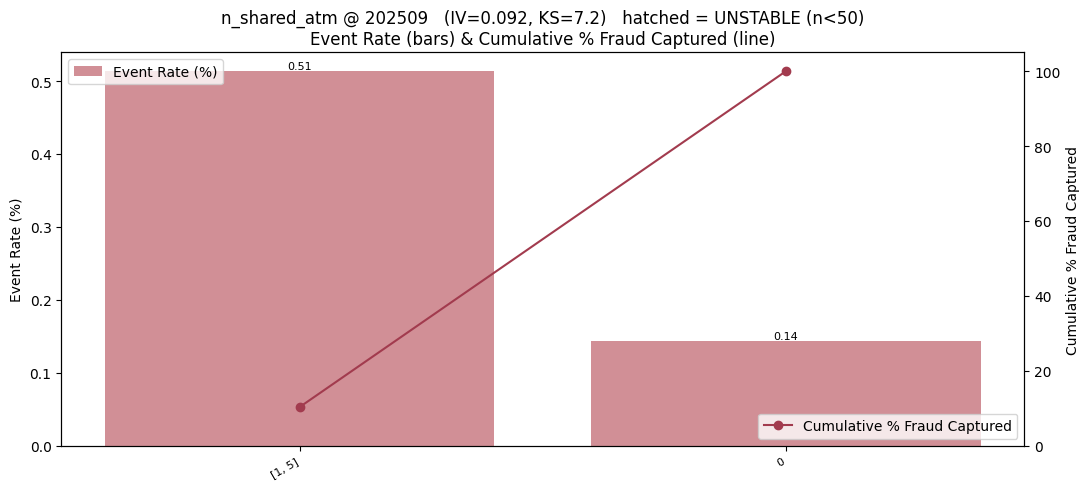

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[1, 5]",10,1947,0.514,0.28,10.31,True
1,0,87,60650,0.143,0.12,100.00,True


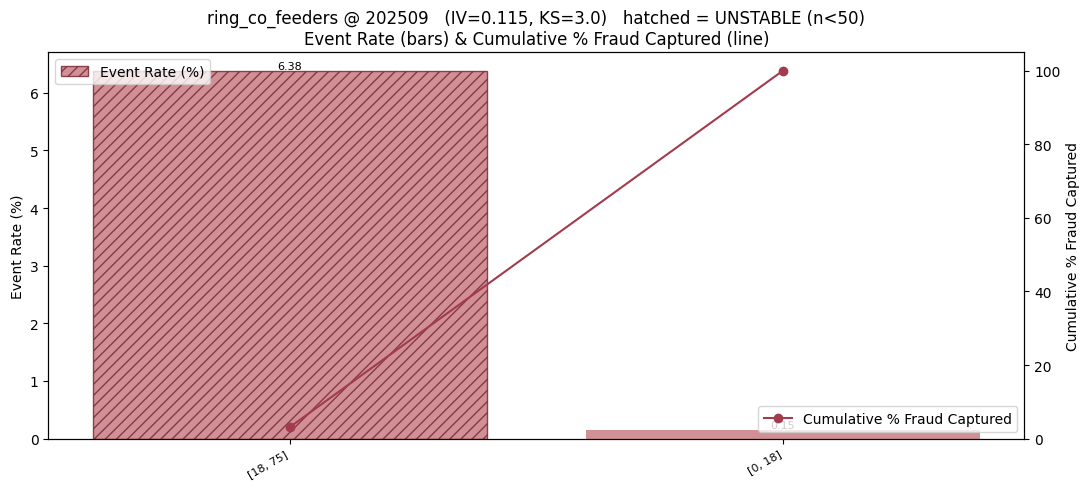

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[18, 75]",3,47,6.383,2.19,3.09,False
1,"[0, 18]",94,62550,0.150,0.12,100.00,True


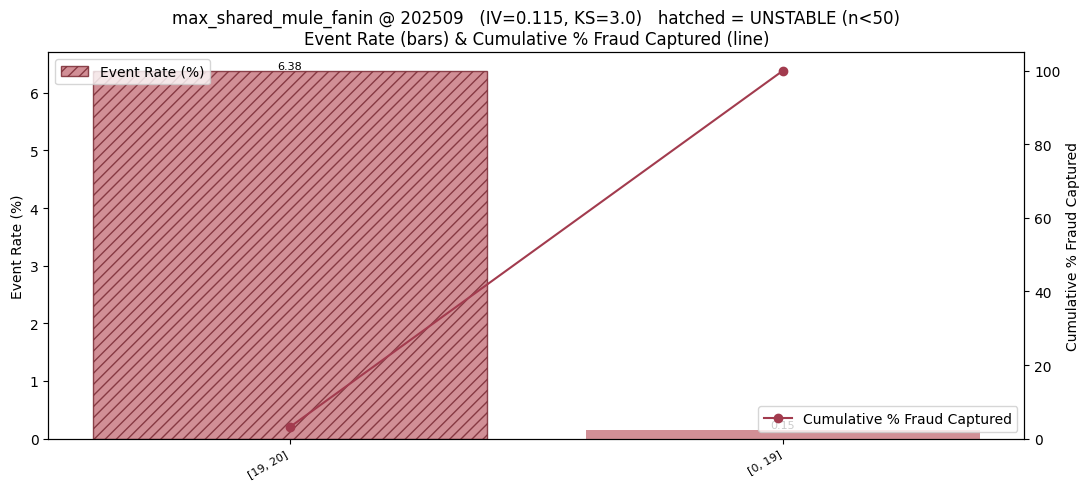

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[19, 20]",3,47,6.383,2.19,3.09,False
1,"[0, 19]",94,62550,0.150,0.12,100.00,True


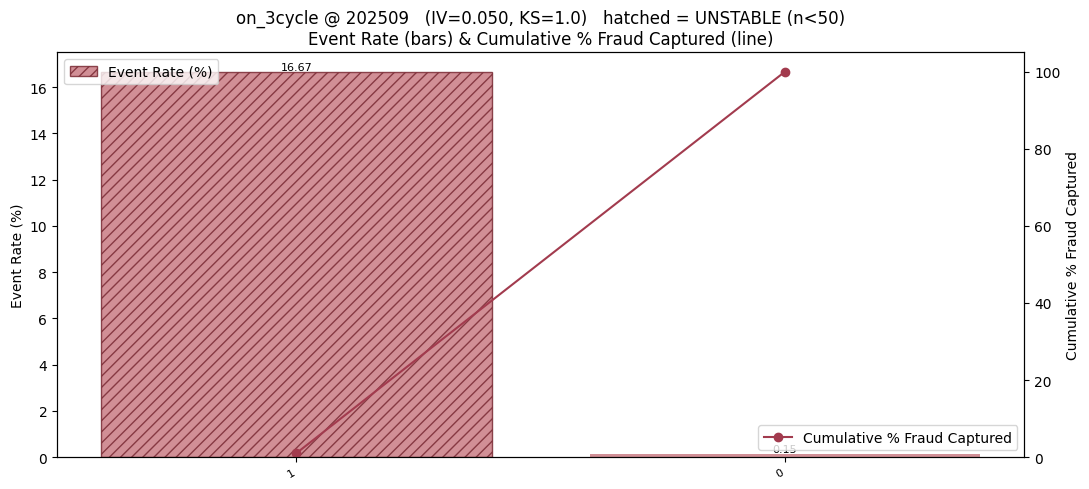

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,1,1,6,16.667,3.01,1.03,False
1,0,96,62591,0.153,0.13,100.00,True


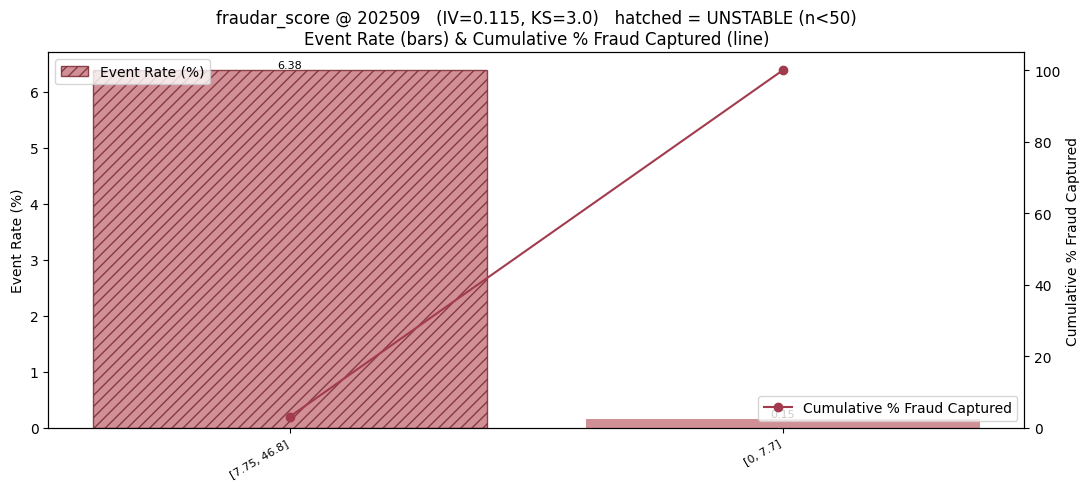

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[7.75, 46.8]",3,47,6.383,2.19,3.09,False
1,"[0, 7.7]",94,62550,0.150,0.12,100.00,True


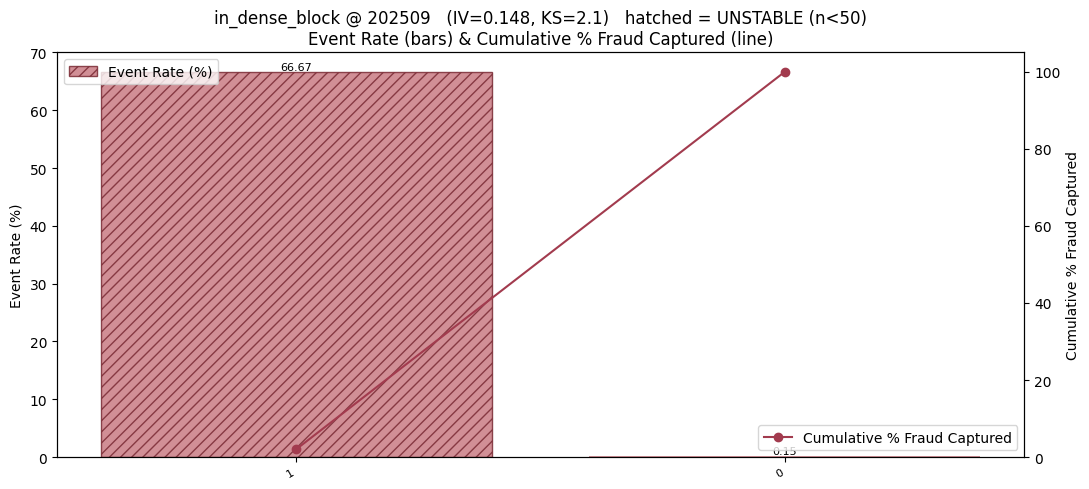

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,1,2,3,66.667,20.77,2.06,False
1,0,95,62594,0.152,0.12,100.00,True


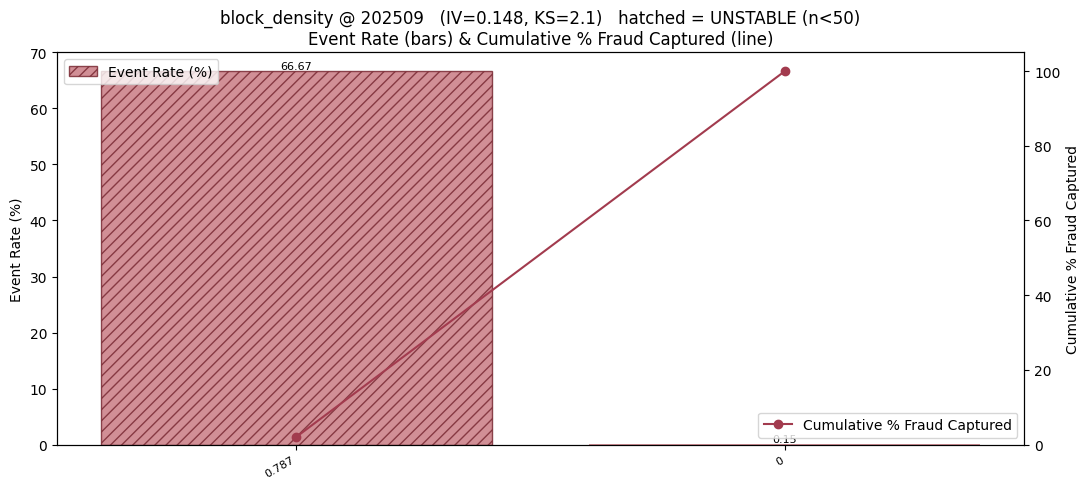

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,0.787,2,3,66.667,20.77,2.06,False
1,0,95,62594,0.152,0.12,100.00,True


26/07/08 06:50:34 ERROR cluster.YarnScheduler: [dispatcher-CoarseGrainedScheduler]: Lost executor 13 on cdhprddn64.axisb.com: Container marked as failed: container_e391_1781430155340_543160_01_000016 on host: cdhprddn64.axisb.com. Exit status: -100. Diagnostics: Container released on a *lost* node.


In [17]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp
from pyspark.sql import functions as _F

CUST_TBL      = "payment_cards_dev.TP99965073_v2_motif_cust_full"
PLOT_FEATURES = ["n_shared_atm", "ring_co_feeders", "max_shared_mule_fanin", "on_3cycle", "fraudar_score", "in_dense_block", "block_density"]
PLOT_ANCHOR   = "202509"     # Sep = most matured; change to inspect another anchor
MIN_BIN_FRAC  = 0.01         # club any bin holding < 1% of customers into its neighbour
MIN_STABLE_CNT= 50           # bin with fewer customers than this is flagged UNSTABLE
MIN_STABLE_BAD= 5            # ...or fewer frauds than this
RISKY_ON_LEFT = True         # True = riskiest bin first (decile/gains look); False = feature-value order

def _wilson_lcb(bad, cnt, z=1.96):
    bad = np.asarray(bad, float); cnt = np.asarray(cnt, float)
    p = np.where(cnt > 0, bad / cnt, 0.0); denom = 1 + z*z/np.maximum(cnt, 1)
    centre = p + z*z/(2*np.maximum(cnt, 1)); margin = z*np.sqrt((p*(1-p) + z*z/(4*np.maximum(cnt,1)))/np.maximum(cnt,1))
    return np.where(cnt > 0, np.clip((centre - margin)/denom, 0, 1), 0.0)

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

def _club_sparse(d, n, min_frac):
    d = d.sort_index().copy()
    while len(d) > 2:
        share = d["cnt"] / n
        if share.min() >= min_frac: break
        j = int(share.values.argmin()); k = j + 1 if j == 0 else j - 1
        lo, hi = min(j, k), max(j, k)
        d.loc[d.index[lo], ["cnt", "bad"]] += d.loc[d.index[hi], ["cnt", "bad"]].values
        d.loc[d.index[lo], "hi"] = max(d.loc[d.index[lo], "hi"], d.loc[d.index[hi], "hi"])
        d.loc[d.index[lo], "lo"] = min(d.loc[d.index[lo], "lo"], d.loc[d.index[hi], "lo"])
        d = d.drop(d.index[hi]).reset_index(drop=True)
    return d

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6); pg = (good / tg).clip(lower=1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_pdf = spark.table(CUST_TBL).where(_F.col("anchor_month") == PLOT_ANCHOR).select("target_fraud", *PLOT_FEATURES).toPandas()
_y = _pdf["target_fraud"].astype(int).values; _tot_bad = int(_y.sum()); _tot_good = len(_y) - _tot_bad
print("plotting anchor %s | customers=%d | frauds=%d" % (PLOT_ANCHOR, len(_pdf), _tot_bad))

def plot_sloping(feature):
    x = _pdf[feature].astype(float).values
    d = (pd.DataFrame({"b": _robust_bins(x), "x": x, "y": _y}).groupby("b")
         .agg(cnt=("y", "size"), bad=("y", "sum"), lo=("x", "min"), hi=("x", "max")).sort_index())
    d = _club_sparse(d, len(_pdf), MIN_BIN_FRAC)
    d = (d.iloc[::-1] if RISKY_ON_LEFT else d).reset_index(drop=True)
    d["event_rate_pct"] = 100.0 * d["bad"] / d["cnt"]
    cum_bad = d["bad"].cumsum(); cum_good = (d["cnt"] - d["bad"]).cumsum()
    d["pct_captured"] = 100.0 * cum_bad / max(_tot_bad, 1)
    ks = float((100.0 * cum_bad / max(_tot_bad, 1) - 100.0 * cum_good / max(_tot_good, 1)).abs().max())
    iv = _woe_iv(d["cnt"], d["bad"])
    d["er_lcb_pct"] = 100.0 * _wilson_lcb(d["bad"].values, d["cnt"].values)
    d["stable"] = (d["cnt"] >= MIN_STABLE_CNT) & (d["bad"] >= MIN_STABLE_BAD)
    labels = [("%.3g" % lo) if lo == hi else ("[%.3g, %.3g]" % (lo, hi)) for lo, hi in zip(d["lo"], d["hi"])]
    xs = range(len(d))
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(xs, d["event_rate_pct"], color="#c97b84", alpha=0.85, label="Event Rate (%)")
    for i, v in enumerate(d["event_rate_pct"]): ax1.text(i, v, "%.2f" % v, ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Event Rate (%)"); ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    for i, st in enumerate(d["stable"].values):
        if not st: ax1.patches[i].set_hatch("///"); ax1.patches[i].set_edgecolor("#7a2a34")
    ax2 = ax1.twinx()
    ax2.plot(xs, d["pct_captured"], color="#a23b4e", marker="o", label="Cumulative % Fraud Captured")
    ax2.set_ylabel("Cumulative % Fraud Captured"); ax2.set_ylim(0, 105)
    ax1.set_title("%s @ %s   (IV=%.3f, KS=%.1f)   hatched = UNSTABLE (n<%d)\nEvent Rate (bars) & Cumulative %% Fraud Captured (line)"
                  % (feature, PLOT_ANCHOR, iv, ks, MIN_STABLE_CNT), fontsize=12)
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); fig.tight_layout(); plt.show()
    _disp.display(pd.DataFrame({"bin": labels, "# frauds": d["bad"].astype(int).values,
                                "# customers": d["cnt"].astype(int).values,
                                "event_rate_%": d["event_rate_pct"].round(3).values,
                                "event_rate_LCB_%": d["er_lcb_pct"].round(2).values,
                                "cum_%_captured": d["pct_captured"].round(2).values,
                                "stable": d["stable"].values}))

for _f in PLOT_FEATURES:
    try: plot_sloping(_f)
    except Exception as _e: print("  %s: skipped (%s)" % (_f, _e))
